# Pytorch 线性回归代码实现

In [2]:
import torch
import matplotlib.pyplot as plt

from torch import nn, optim  # 神经网络模型和优化器
from torch.utils.data import TensorDataset, DataLoader #构建数据集和数据加载器

In [3]:
# 构建数据集和数据加载器
X = torch.randn(100,1)
# 预设真实系数,随便给的两个数
w = torch.tensor([2.5])
b = torch.tensor([5.2])

# 定义随机噪声
noise = torch.randn(100,1) * 0.1

# 定义拟合的目标值
y = w * X + b + noise

# 构建数据集
dataset = TensorDataset(X, y)

# 构建数据加载器
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

In [4]:
# 2. 构建模型
model = nn.Linear(in_features=1, out_features=1)

In [5]:
# 3. 构建损失函数和优化器
loss = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)

In [6]:
# 4. 训练模型
epoch_num = 1000
loss_list = []
for epoch in range(epoch_num):
    total_loss = 0   # 本轮总损失
    iter_number = 0  # 本轮的迭代次数
    # 一个轮次的迭代
    for x_train, y_train in dataloader:
        # 4.1 前向传播
        y_pred = model(x_train)
        # 4.2 计算损失
        loss_value = loss(y_pred, y_train)
        total_loss += loss_value
        iter_number += 1
        # 4.3 反向传播
        loss_value.backward()
        # 4.4 更新参数
        optimizer.step()
        # 4.5 梯度清零
        optimizer.zero_grad()
    # 计算本轮平均损失
    loss_list.append(total_loss / iter_number)

# 训练完成打印模型参数
print(model.weight)
print(model.bias)
        

Parameter containing:
tensor([[2.5066]], requires_grad=True)
Parameter containing:
tensor([5.2083], requires_grad=True)


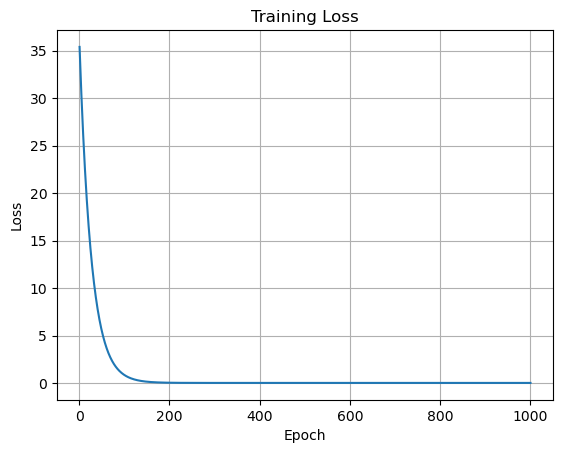

In [7]:
# 将 loss_list 中的 tensor 转换为 float
loss_values = [l.item() for l in loss_list]

# 画图
fig, ax = plt.subplots()
ax.plot(range(1, epoch_num + 1), loss_values)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True)
plt.show()